# 必要なモジュールのインポート

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 仮説検定の考え方

## 例題 1

コインを$20$枚投げたところ，そのうち$15$回で表が出た．
この結果から，このコインは（例えば歪みや細工により）裏よりも表が出やすいと判断してよいだろうか．
$$
H_0 \colon p = 0.5 \\
H_1 \colon p \neq 0.5
$$
として，有意水準$5\%$で両側検定したい．
どのような計算を行えばよいか，下のセルにコードを書け．

##### ヒント

二項分布$B(N,p)$の累積分布関数$F(t) = P(X \leqq t)$は，次のコードが利用できる．
```
stats.binom.cdf(t, N, p)
```

In [2]:
# ここにコードを書く
if 1 - stats.binom.cdf(15-1,20,0.5) > 0.025:
    print("コイントスで15回以上表が出る確率は{:.3f}であり，有意水準5%でH_0は棄却されない".format(1 - stats.binom.cdf(15-1,20,0.5)))
else:
    print("コイントスで15回以上表が出る確率は{:.3f}であり，有意水準5%でH_0は棄却される".format(1 - stats.binom.cdf(15-1,20,0.5)))

コイントスで15回以上表が出る確率は0.021であり，有意水準5%でH_0は棄却される


## 例題 1

表が出やすくなるように，コインの片面に細工を施した．
このコインを$20$枚投げたところ，そのうち$14$回で表が出た．
この結果から，このコインは裏よりも表が出やすくなったと判断してよいだろうか．
$$
H_0 \colon p = 0.5 \\
H_1 \colon p > 0.5
$$
として，有意水準$5\%$で片側検定したい．
どのような計算を行えばよいか，下のセルにコードを書け．

また，検定結果を下のセルに記述せよ．

In [3]:
# ここにコードを書く
result = 1 - stats.binom.cdf(14-1,20,0.5)
result.item()

0.057659149169921875

#### 検定結果

（ここに検定の結果を書き込む）

コインを$20$回投げて$14$回以上表が出る確率は，$0.058$であり，片側有意水準の$0.05$より大きい．

ゆえに，有意水準$5\%$の片側検定により，帰無仮説$H_0$は棄却されない．

# t分布とt検定

## 問題-2

標準正規分布$N(0,1)$の確率密度関数のグラフと，次のt分布の確率密度関数のグラフを，区間$[-3,3]$においてそれぞれ重ねて表示せよ．

また，自由度$n$を変化させることで，$N(0,1)$と$t_n$の確率密度関数のグラフの間に見られる関係について考察せよ．

##### ヒント

自由度$n$のt分布の確率密度関数のグラフの描画には，次が使える．
```
# dfが自由度
stat.t.pdf(x,df=n)
```

なお，標準正規分布の確率密度関数のグラフの描画は，次のコードを利用してよい．


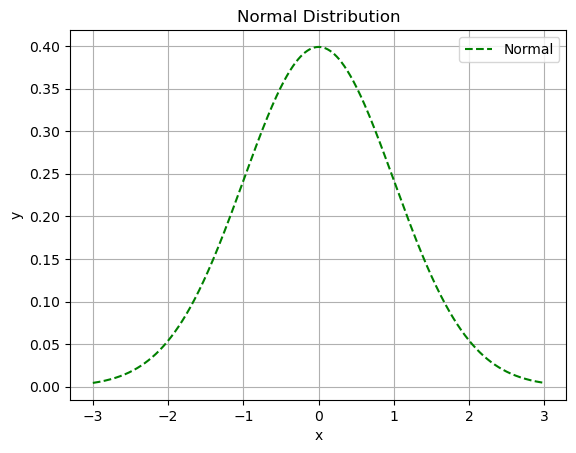

In [4]:
x = np.arange(-3,3,0.01)

# 正規分布の確率密度関数を，緑色，破線で描画する
plt.plot(x,stats.norm.pdf(x,loc=0,scale=1), "--", color="green", label="Normal")
plt.title("Normal Distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

1. $t_2$

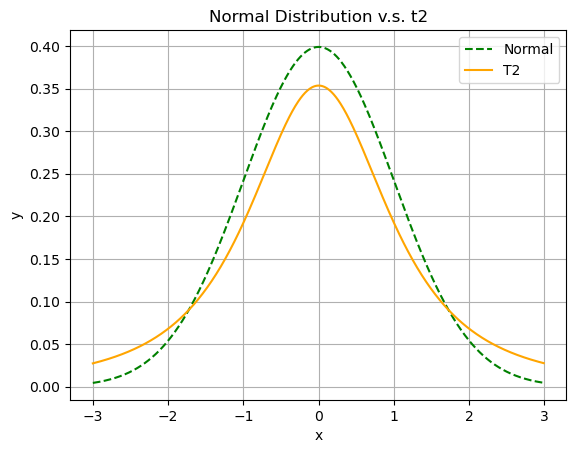

In [5]:
x = np.arange(-3,3,0.01)

plt.plot(x,stats.norm.pdf(x,loc=0,scale=1), "--", color="green", label="Normal")
plt.plot(x,stats.t.pdf(x,df=2), color="orange", label="T2")
plt.title("Normal Distribution v.s. t2")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


2. $t_{10}$

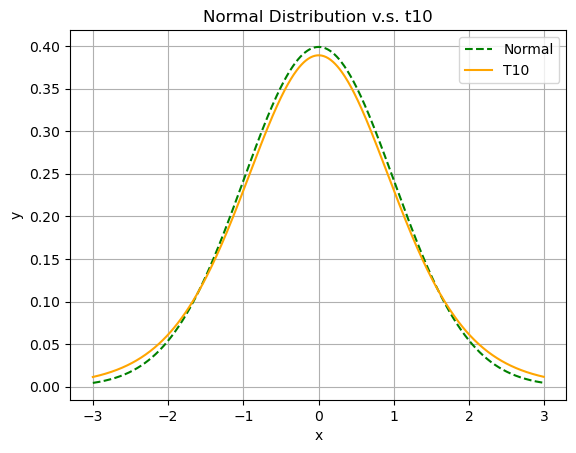

In [6]:
x = np.arange(-3,3,0.01)

plt.plot(x,stats.norm.pdf(x,loc=0,scale=1), "--", color="green", label="Normal")
plt.plot(x,stats.t.pdf(x,df=10), color="orange", label="T10")
plt.title("Normal Distribution v.s. t10")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


3. $t_{30}$

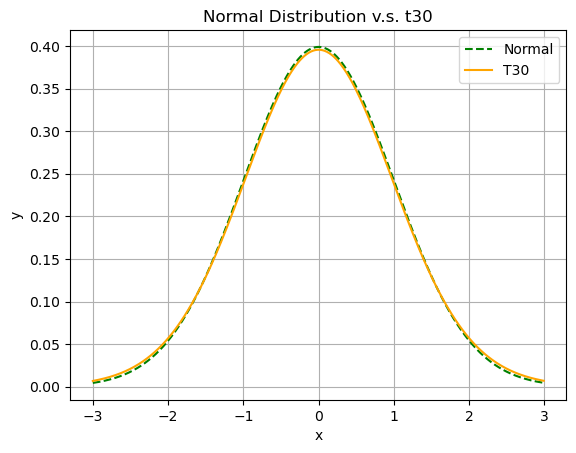

In [7]:
x = np.arange(-3,3,0.01)

plt.plot(x,stats.norm.pdf(x,loc=0,scale=1), "--", color="green", label="Normal")
plt.plot(x,stats.t.pdf(x,df=30), color="orange", label="T30")
plt.title("Normal Distribution v.s. t30")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


4. $t_{100}$

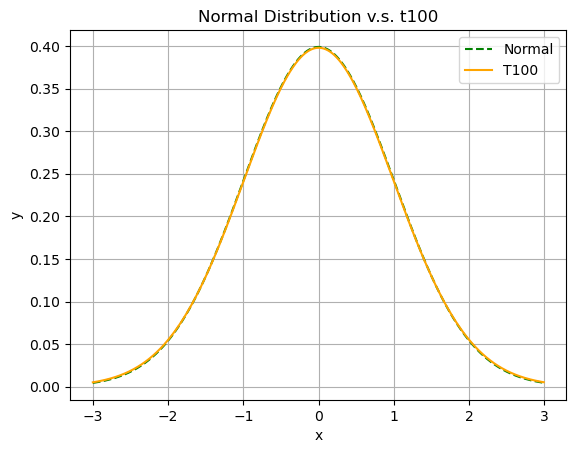

In [8]:
x = np.arange(-3,3,0.01)

plt.plot(x,stats.norm.pdf(x,loc=0,scale=1), "--", color="green", label="Normal")
plt.plot(x,stats.t.pdf(x,df=100), color="orange", label="T100")
plt.title("Normal Distribution v.s. t100")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


#### 考察

自由度$n$が大きくなるほど，t分布と標準正規分布の確率密度関数のグラフは近寄って見える．


## 例題2-問題3

ある機械で生産された$10$個の製品の重量を測定したところ
$$
101.1, 103.2. 102.1, 99.2, 100.5, 101.3, 99.7, 100.5, 98.9, 101.4 \quad [\text{g}]
$$
のような結果を得た．

測定結果については，次のコードから取得せよ．

In [10]:
data = [101.1, 103.2, 102.1, 99.2, 100.5, 101.3, 99.7, 100.5, 98.9, 101.4]
series = pd.Series(data)

0. （仮説の設定）母平均は$100\text{g}$と考えてよいだろうか．
この検証のために，仮説検定を行いたい．
帰無仮説$H_0$と対立仮説は何であるべきか．
下のセルに書き込め．

帰無仮説$H_0$: $\mu = 100$

対立仮説$H_1$: $\mu \neq 100$

1. （直接立式して計算）母平均は$100\text{g}$と考えてよいだろうか．
次の手順で計算を行うことにより，有意水準$5\%$で検定せよ．
必要ならば，コード記述欄の下の**ヒント**も参考にせよ．

    1. `series`に含まれるデータの平均と不偏標本分散の正の平方根を，それぞれ変数`m`，`s`に入れる．
    1. `u`にt分布の上位$2.5\\%$点の値を入れる．
    1. t統計量`t`を計算する．
    1. `t>=0`ならば，`t`と`u`の値を比較する．（帰無仮説$H_0$が棄却できないときに，ブール値`True`を吐くようにするにはどうすればよいだろうか．）`t<0`ならば，`-t`と`u`の値を比較する．帰無仮説$H_0$が棄却される場合は`False`，棄却されない場合は`True`を表示するようにせよ．


In [11]:
m = np.mean(series)
s = np.std(series, ddof=1)
t = (m - 100)/(s/np.sqrt(10))
u = stats.t.ppf(0.975,df=9)
print("t統計量: {:.3f}，上位2.5%点: {:.3f}".format(t,u))
if t >= 0:
    print(t < u)
else:
    print(-t < u)

t統計量: 1.891，上位2.5%点: 2.262
True


##### ヒント

* `Series`オブジェクトに対しては，`numpy`モジュールの関数`np.mean(Series)`，`np.var(Series,ddof=1)`でそれぞれ標本平均，不偏標本分散が計算できる．`np.var()`の`ddof`の値を`0`にすると，不偏でない標本分散（データを母集団とみなした分散），`1`にすると，不偏標本分散（データを母集団から抽出した標本とみなした分散）が計算される．

* 数値に対して，その平方根を計算するには，`numpy`モジュールの関数`np.sqrt()`が利用できる．
なお，`np.sqrt(np.var())`は，標準偏差を与える関数`np.std()`と同等である．関数`np.std()`においても`ddof`の値を設定できる．

* 自由度`n`のt分布の上位$100\alpha\%$点を与える関数は，`scipy.stats`で提供されている
```
stats.t.ppf(1-a,df=n)
```
が利用できる．
    * （補足）`1-a`の理由: 統計学の教科書では，通常$100\alpha\%$点というと上から$100\alpha\%$の$x$座標を表すのであるが，pythonでは下から$100\alpha\%$の$x$座標を表す流儀（つまり累積分布関数の逆関数）のようである．

* 不等式や等式は，ブール値（「真（`True`）」「偽（`False`）」の$2$値）として扱われる．
```
2 < 3 # 実行すると「True」が表示される．以下同様
2 > 3 # False
2 == 3 # False
2 != 3 # True
```

    * （補足）ブール値は，`and`，`or`，`not`を演算子にもつブール代数をなす．
    ```
    True and False # False
    True or False # True
    not True # False
    ```

2. （関数利用）母平均は$100\text{g}$と考えてよいだろうか．
次の手順で計算を行うことにより，有意水準$5\%$で検定せよ．

    1. `stats.ttest_1samp(Data, Popmean)`で標本`Data`と帰無仮説で仮定する母平均`Popmean`から，自動的に取得された自由度によるt分布の検定統計量`t`と$p$値`p`（検定統計量`t`の，分布の上位または下位からの割合の小さいほう）が得られる．構文は
```
t, p = stats.ttest_1samp(Data, Popmean)
```
である．

    2. 求めるべきは，この$p$値`p`が有意水準の半分である$0.025$より小さいか否かである．$p>0.025$であるとき，`t`統計量の値はそれほど稀な事象ではないということであり，帰無仮説$H_0$は棄却されない．$p<0.025$のとき，帰無仮説$H_0$は棄却される．よって，`p>0.025`となるときに`True`が吐き出されるようにすればよい．

In [12]:
t, p = stats.ttest_1samp(series,100)
print("t統計量: {:.3f}，p値: {:.3f}".format(t,p))
print(p > 0.025)

t統計量: 1.891，p値: 0.091
True


3. （復習，直接立式して計算）上の測定結果をもとに，製品の重量の母平均の信頼度$95\%$信頼区間を求めよ．
また，上の検定結果と比較し，それぞれの意味について考察せよ．

なお，自由度$n$のt分布の$2.5\%$点を$t_{n,0.025}$と表すと，信頼度$95\%$の信頼区間における上側信頼限界，下側信頼限界はそれぞれ
$$
\overline{x} \pm t_{n, 0.025} \cdot \frac{\hat{s}}{\sqrt{n}}
$$

In [13]:
d = stats.t.ppf(0.975,df=9)*s/np.sqrt(10)
print("95%信頼区間は，[{:.3f},{:.3f}]で与えられる".format(m-d,m+d))

95%信頼区間は，[99.845,101.735]で与えられる


4. （関数利用）上の測定結果をもとに，次の手順に従い，製品の重量の母平均の信頼度$95\%$信頼区間を求めよ．

    1. 不偏分散を$\hat{S}^2$とすると，大きさ$n$の標本の**標準誤差**（標本平均の標準偏差）は$\hat{S}/\sqrt{n}$と書ける．
この標準誤差を`seq`に格納すると，母平均の信頼度$100\alpha\%$信頼区間は，
```
# m: 標本平均，n-1: 自由度，100*a: 信頼度
stats.t.interval(alpha=a, df=n-1, loc=m, scale=sep)
```
で計算される．

In [14]:
sep = s / np.sqrt(10)
low, high = stats.t.interval(confidence=0.95, df=9, loc=m, scale=sep)
print(f"信頼区間: ({float(low):.3f}, {float(high):.3f})")

信頼区間: (99.845, 101.735)


In [15]:
# いつものモジュールのインポート
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 検出力

A商店では，新製品のクッキー（A）の市場での評価を試験するために，試食会において従来品のクッキー（B)と比較して，どちらをより好むかについてのアンケートをとった．その結果が次の通りである．

| | A | B | 計 |
| ---- | ---- | ---- | ---- |
| どちらを好むか | 10 | 5 | 15 |

1. アンケートをとった人数（標本の大きさ）を$N$，Aのクッキーを好むとした人の割合を$p_{\text{sample}}$とする．\
まず，$N$（`N`），$p_{\text{sample}}$（`p_sample`）に，アンケートの結果から分かる適切な数値を入力せよ．\
次に，この標本から無作為に1人を抽出したとき，その1人の回答の仕方は二項分布$B(1,p_{\text{sample}})$に従うとみなせる．この分布の分散$v$を`v`に入力せよ．

この計算結果（$p_{\text{sample}}$，$v$）は，母集団（顧客全体）から無作為に1人を抽出したとき，Aを選択する確率$p$に関する推定量の分布を与える．

In [16]:
N = 15
p_sample = 10 / 15
v = p_sample * (1-p_sample)

2. この結果から，新製品のクッキーがより好まれると結論付けてよいだろうか．
母集団におけるAを選択する確率$p$について，
$$
H_0 \colon p = 0.5, \quad H_1 \colon p > 0.5
$$
とし，有意水準$5\%$の右片側検定により，判断せよ．
ただし，母集団の分散は標本分散$v$に等しく既知であるとし，二項分布の正規分布への近似を利用し，z検定を行うこと．
また，検定の根拠となる`p_sample`及び`ppt`の値も明示すること．\
ヒント:
  1. 帰無仮説$H_0 \colon p = 0.5$に基づく，（右片側検定であるから）上位$5\%$点を`ppt`に格納するには，次の書式を利用する．
  ```
  ppt = stats.norm.ppf(0.95,loc=0.5,scale=標準偏差)
  ```
  （`stats.norm.ppf(x,loc=平均,scale=標準偏差)`は，正規分布で下から数えてxとなる$x$座標を与える．つまり累積分布関数の逆関数である）．\
  ここで，今回は標本数が`N`の標本調査を行っているため，標準偏差の計算にあたり，上で定義した`v`を直接利用するのではないことに注意されたい．また，平方根の計算には，`np.sqrt()`関数を利用せよ．

In [17]:
percent = 0.95

ppt = stats.norm.ppf(0.95,loc=0.5,scale=np.sqrt(v/N))

print("p_sample={:.4f}，上位5%点はppt={:.4f}である．".format(p_sample,ppt))
if p_sample < ppt:
  print("p_sample<pptであるため，H_0は棄却されず，クッキーAがより好まれるとは言えない．")
else:
  print("p_sample>pptであるため，H_0は棄却され，クッキーAがより好まれると言える．")

p_sample=0.6667，上位5%点はppt=0.7002である．
p_sample<pptであるため，H_0は棄却されず，クッキーAがより好まれるとは言えない．


3. この検定の検出力を求めよ．
効果量は$\Delta = 0.1$とする．\
手順:
  1. 効果量`Delta`に，$0.1$を入力する．
  2. $H_1 \colon p = 0.5 + \Delta$のもとで，第2種の誤りを犯す確率$\beta$を求める．
  $H_1$が採択されるべきにも関わらず$H_0$が棄却できない確率が$\beta$であるから，$H_1$に基づく分布の下で，（右片側検定を行っているので）大きさ`N`の標本から求めた$p$の標本平均が上で求めた`ppt`を下回る確率を求めればよい．
  このためには，
  ```
  beta = stats.norm.cdf(ppt,loc=効果量を加味した母平均,scale=標準偏差)
  ```
  とすればよい（`stats.norm.cdf(x)`は`x`までの累積分布関数の値，`x`以下の確率の総和である）．
  3. 検出力は，効果量$\Delta$に基づく$1-\beta$で計算される．
  `1-beta`を出力せよ:
  ```
  print("Delta={}としたときのこの検定の検出力は，{:.4f}である．".format(Delta,1-beta))
  ```

In [18]:
Delta = 0.1
beta = stats.norm.cdf(ppt,loc=0.5+Delta,scale=np.sqrt(v/N))

print("Delta={}としたときのこの検定の検出力は，{:.4f}である．".format(Delta,1-beta))

Delta=0.1としたときのこの検定の検出力は，0.2052である．


4. この検定の検出力を$80\%$（$0.80$）としたいとき，次の考えに従って，適切な標本数（アンケート実施人数）$n$を求める式を入力し，計算結果を出力せよ．

  1. 帰無仮説$H_0 \colon p = 0.5$に基づいて$p = 0.5$とした母集団の分布における，上側$5\%$点$x_{\text{ppt}}$を与える式は
  $$
  x_{\text{ppt}} = 0.5 + z(0.05) \cdot \sqrt{ \frac{p(1-p)}{n} }  \quad (\text{$z(0.05)$は標準正規分布における上側$5\%$点を与える座標})
  $$
  である．
  今回は，問題の設定上，先に得られた標本分散を母分散として用いるため，上式の根号の中では$p = p_{\text{sample}}$として計算する．
  2. 効果量を$\Delta=0.1$とすると，$H_1 \colon p = 0.5 + \Delta$に基づく母集団の分布における，（右片側検定であるから）下側$20\%$点を与える式は
  $$
  x_{\text{beta_bound}} = 0.5 + \Delta - z(0.20) \cdot \sqrt{ \frac{p(1-p)}{n} }
  $$
  で与えられる．この式においても，根号の中では$p = p_{\text{sample}}$の値を用いる．
  3. $x_{\text{ppt}} = x_{\text{beta_bound}}$として，$n$に関する方程式とみなして，$n$について解く．
  実数解$n$に最も近い整数値（`round(n)`）が，今回求めるべき標本数である．
  
  ヒント:
  標準正規分布における上側$100\alpha\%$点$z(\alpha)$を求めるコードは（平均`0`，標準偏差`1`とすればよいから）
  ```
  stats.norm.ppt(1-0.05,loc=0,scale=1)
  ```
  を利用せよ．
  
  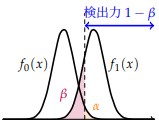

In [19]:
ppt_0 = stats.norm.ppf(0.95,loc=0,scale=1) # H_0の下での標準正規分布の上側5%点
ppt_1 = stats.norm.ppf(0.80,loc=0,scale=1) #H_1の下での標準正規分布の上側20%点
n = ( (ppt_0 + ppt_1) / Delta )**2 * p_sample * (1 - p_sample)
print("検出力が0.80に一番近くなる標本の大きさは，n={}である．".format(round(n)))

検出力が0.80に一番近くなる標本の大きさは，n=137である．


最後に，答え合わせのために，次のコードを実行してみよ（正しい`v`が，上のセルで入力されている必要がある）．

In [20]:
for n in range(1,1000):
  beta = stats.norm.cdf(stats.norm.ppf(0.95,loc=0.5,scale=np.sqrt(v/n)),loc=0.5+Delta,scale=np.sqrt(v/n))
  print("n={}のとき，検出力は{:.4f}である．".format(n,1 - beta))

n=1のとき，検出力は0.0760である．
n=2のとき，検出力は0.0893である．
n=3のとき，検出力は0.1007である．
n=4のとき，検出力は0.1111である．
n=5のとき，検出力は0.1209である．
n=6のとき，検出力は0.1302である．
n=7のとき，検出力は0.1393である．
n=8のとき，検出力は0.1480である．
n=9のとき，検出力は0.1566である．
n=10のとき，検出力は0.1650である．
n=11のとき，検出力は0.1733である．
n=12のとき，検出力は0.1814である．
n=13のとき，検出力は0.1894である．
n=14のとき，検出力は0.1973である．
n=15のとき，検出力は0.2052である．
n=16のとき，検出力は0.2129である．
n=17のとき，検出力は0.2206である．
n=18のとき，検出力は0.2282である．
n=19のとき，検出力は0.2357である．
n=20のとき，検出力は0.2432である．
n=21のとき，検出力は0.2506である．
n=22のとき，検出力は0.2579である．
n=23のとき，検出力は0.2652である．
n=24のとき，検出力は0.2724である．
n=25のとき，検出力は0.2795である．
n=26のとき，検出力は0.2867である．
n=27のとき，検出力は0.2937である．
n=28のとき，検出力は0.3007である．
n=29のとき，検出力は0.3077である．
n=30のとき，検出力は0.3146である．
n=31のとき，検出力は0.3214である．
n=32のとき，検出力は0.3282である．
n=33のとき，検出力は0.3350である．
n=34のとき，検出力は0.3417である．
n=35のとき，検出力は0.3483である．
n=36のとき，検出力は0.3549である．
n=37のとき，検出力は0.3615である．
n=38のとき，検出力は0.3680である．
n=39のとき，検出力は0.3745である．
n=40のとき，検出力は0.3809である．
n=41のとき，検出力は0.3872である．
n=42のとき，検出力は0.3935である．
n=43のとき，検出力は0.3998である．
n=44のとき，検出力は0.4060であ

# 対応のある検定

配布ファイル`2026_02_Tempo_Kanto.csv`に記録されている，2026年2月の東京，横浜，さいたま、千葉の日毎平均気温のデータをもとに，この4地点の2月の気温について，差があるかどうか判断したい．

0. まずは，変数を標準化してt統計量をつくるための関数を用意しておく．
$$
t = \frac{m}{\sqrt{v/\nu}} \quad (\text{$m$: 平均，$v$: 標本分散，$\nu$: 標本の大きさ})
$$

In [21]:
def t_val(m,v,nu): # m: 平均，v: 標本分散，nu: 標本の大きさ
  return m / np.sqrt(v / nu)

1. まず，`df1`に配布ファイル`2026_02_Tempo_Kanto.csv`のデータを読み込もう．
データの読み込みには，以下のコードを利用せよ．
```
df1 = pd.read_csv("/content/drive/MyDrive/.../2026_02_Tempo_Kanto.csv")
```
ここでの`"/content/drive/MyDrive/.../12026_02_Tempo_Kanto.csv"`は，配布された`2026_02_Tempo_Kanto.csv`のドライブ上の保存場所（パス）と配布データセットのファイル名を表す．
各自で適切なものを設定すること．

正しく読み込めているかを，`df1`の最初の数行を出力することで確認せよ．
コードは
```
df1.head()
```
が利用できる．

In [22]:
df1 = pd.read_csv("2026_02_Tempo_Kanto.csv")
df1.head()

,2026_02,東京,横浜,さいたま,千葉
0,1,5.5,6.2,3.5,5.9
1,2,6.4,6.9,4.7,6.6
2,3,5.8,6.7,4.2,6.1
3,4,6.3,6.8,4.0,6.8
4,5,7.8,8.4,5.8,8.3


2. `df1`に，東京と横浜の気温差
$$
(\text{東京}) - (\text{横浜})
$$
の列を追加せよ．
列のタイトルは，「東京vs横浜」とせよ．

  ヒント:
  1. データフレーム`df1`の「東京」列のデータを取り出すには，`df1["東京"]`とすればよい．
  2. データフレーム`df1`に，「東京」列と「横浜」列の各データの和の列を「東京+横浜」という列タイトルで追加するには，
  ```
  df1["東京+横浜"] = df1["東京"] + df1["横浜"]
  ```
  とすればよい．

In [23]:
df1["東京vs横浜"] = df1["東京"] - df1["横浜"]
df1.head()

,2026_02,東京,横浜,さいたま,千葉,東京vs横浜
0,1,5.5,6.2,3.5,5.9,-0.7
1,2,6.4,6.9,4.7,6.6,-0.5
2,3,5.8,6.7,4.2,6.1,-0.9
3,4,6.3,6.8,4.0,6.8,-0.5
4,5,7.8,8.4,5.8,8.3,-0.6


3. データフレーム`df1`の「東京vs横浜」列のデータの平均，不偏標本分散，標本の大きさをそれぞれ`mean_tokyo_yokohama`，`var_tokyo_yokohama`，`len_tokyo_yokohama`に格納し，その結果を表示せよ．

  ヒント:
  1. データの平均を求めるには，`np.mean(データ)`関数が使える．
  2. データの分散を求めるには，`np.var(データ,ddof=r)`関数が使える．
  ここで，`ddof`の値は，$(\text{標本数})-(\text{自由度})$，すなわち束縛条件の数である．
  今回は，`ddof=1`とする．
  3. 標本の大きさを求めるには，`len(データ)`が使える．

In [24]:
mean_tokyo_yokohama, var_tokyo_yokohama, len_tokyo_yokohama = np.mean(df1["東京vs横浜"]), np.var(df1["東京vs横浜"],ddof=1),len(df1)
print("東京と横浜の気温差の平均は{:.4f}，不偏標本分散は{:.4f}，標本数は{}である．".format(mean_tokyo_yokohama,var_tokyo_yokohama,len_tokyo_yokohama))

東京と横浜の気温差の平均は-0.4893，不偏標本分散は0.2440，標本数は28である．


4. 東京と横浜に気温差が認められるか否かについて，気温差が正規分布に従うと仮定し，
$$
H_0 \colon \mu_d = 0, \quad H_1 \colon \mu_d \neq 0 \qquad (\text{$\mu_d$は気温差の平均})
$$
として，有意水準$5\%$の両側t検定を行え．
検定の根拠となるt統計量，およびt分布の上側パーセント点も表示すること．

  ヒント:
  1. 東京と横浜の気温差のt統計量は，上で定義した`t_val()`を使え．
  2. （両側検定であるから）自由度`n-1`のt分布の上側$100 \alpha / 2\%$点の座標を与える関数は，
  ```
  t_ppt = stats.t.ppf(1 - a/2, n - 1)
  ```
  を利用せよ．

In [25]:
t_tokyo_yokohama = t_val(mean_tokyo_yokohama, var_tokyo_yokohama, len_tokyo_yokohama)
t_ppt = stats.t.ppf(0.975,len_tokyo_yokohama-1)
print("東京と横浜の2月の気温差のt統計量は{:.4f}であり，自由度{}のt分布における上側2.5%点は{:.4f}である．".format(t_tokyo_yokohama, len_tokyo_yokohama-1, t_ppt))

if abs(t_tokyo_yokohama) < t_ppt:
  print("H_0は棄却されず，東京と横浜の2月の日毎平均気温に差はあるとはいえない．")
else:
  print("H_0は棄却され，東京と横浜の2月の日毎平均気温に差はあるといえる．")

東京と横浜の2月の気温差のt統計量は-5.2419であり，自由度27のt分布における上側2.5%点は2.0518である．
H_0は棄却され，東京と横浜の2月の日毎平均気温に差はあるといえる．


5. 同様の手続きにより，東京と横浜に気温差があるか否かについて，
$$
H_0 \colon \mu_d = 0, \quad H_1 \colon \mu_d \neq 0
$$
とした有意水準$5%$の両側t検定を行え．

In [26]:
# 東京と千葉の気温差をdf1の「東京vs千葉」列に格納する
df1["東京vs千葉"] = df1["東京"] - df1["千葉"]
df1.head()

,2026_02,東京,横浜,さいたま,千葉,東京vs横浜,東京vs千葉
0,1,5.5,6.2,3.5,5.9,-0.7,-0.4
1,2,6.4,6.9,4.7,6.6,-0.5,-0.2
2,3,5.8,6.7,4.2,6.1,-0.9,-0.3
3,4,6.3,6.8,4.0,6.8,-0.5,-0.5
4,5,7.8,8.4,5.8,8.3,-0.6,-0.5


In [27]:
# 東京と千葉の気温差の平均，分散，標本の大きさをそれぞれの変数に格納する

mean_tokyo_chiba, var_tokyo_chiba, len_tokyo_chiba = np.mean(df1["東京vs千葉"]), np.var(df1["東京vs千葉"],ddof=1), len(df1)

# t統計量を求める（上側2.5%点はすでに横浜との対比のところで作ったt_pptを利用すればよい）

t_tokyo_chiba = t_val(mean_tokyo_chiba, var_tokyo_chiba, len_tokyo_chiba)

# 統計b量を比較し，検定結果を表示する

print("東京と千葉の2月の気温差のt統計量は{:.4f}であり，自由度{}のt分布における上側2.5%点は{:.4f}である．".format(t_tokyo_chiba, len_tokyo_chiba-1, t_ppt))

if abs(t_tokyo_chiba) < t_ppt:
  print("H_0は棄却されず，東京と千葉の2月の日毎平均気温に差はあるとはいえない．")
else:
  print("H_0は棄却され，東京と千葉の2月の日毎平均気温に差はあるといえる．")

東京と千葉の2月の気温差のt統計量は-4.8987であり，自由度27のt分布における上側2.5%点は2.0518である．
H_0は棄却され，東京と千葉の2月の日毎平均気温に差はあるといえる．


In [28]:
# 横浜と千葉の気温差をdf1の「横浜vs千葉」列に格納する
df1["横浜vs千葉"] = df1["横浜"] - df1["千葉"]
df1.head()

,2026_02,東京,横浜,さいたま,千葉,東京vs横浜,東京vs千葉,横浜vs千葉
0,1,5.5,6.2,3.5,5.9,-0.7,-0.4,0.3
1,2,6.4,6.9,4.7,6.6,-0.5,-0.2,0.3
2,3,5.8,6.7,4.2,6.1,-0.9,-0.3,0.6
3,4,6.3,6.8,4.0,6.8,-0.5,-0.5,0.0
4,5,7.8,8.4,5.8,8.3,-0.6,-0.5,0.1


In [29]:
# 横浜と千葉の気温差の平均，分散，標本の大きさをそれぞれの変数に格納する

mean_yokohama_chiba, var_yokohama_chiba, len_yokohama_chiba = np.mean(df1["横浜vs千葉"]), np.var(df1["横浜vs千葉"],ddof=1), len(df1)

# t統計量を求める（上側2.5%点はすでに横浜との対比のところで作ったt_pptを利用すればよい）

t_yokohama_chiba = t_val(mean_yokohama_chiba, var_yokohama_chiba, len_yokohama_chiba)

# 統計b量を比較し，検定結果を表示する

print("横浜と千葉の2月の気温差のt統計量は{:.4f}であり，自由度{}のt分布における上側2.5%点は{:.4f}である．".format(t_yokohama_chiba, len_yokohama_chiba-1, t_ppt))

if abs(t_yokohama_chiba) < t_ppt:
  print("H_0は棄却されず，横浜と千葉の2月の日毎平均気温に差はあるとはいえない．")
else:
  print("H_0は棄却され，横浜と千葉の2月の日毎平均気温に差はあるといえる．")

横浜と千葉の2月の気温差のt統計量は-0.7461であり，自由度27のt分布における上側2.5%点は2.0518である．
H_0は棄却されず，横浜と千葉の2月の日毎平均気温に差はあるとはいえない．


# Welch's t-Test

配布ファイル`116_AvsB.csv`には，40人にA，Bの2種類の問題集を無作為に割り当てて使用してもらい，使用の前後に受験したテストの成績を記録している（データは架空です）．


1. まず，`df2`に配布ファイル`116_AvsB.csv`のデータを読み込もう．
データの読み込みには，以下のコードを利用せよ．
```
df2 = pd.read_csv("/content/drive/MyDrive/.../116_AvsB.csv")
```
ここでの`"/content/drive/MyDrive/.../116_AvsB.csv"`は，配布された`116_AvsB.csv`のドライブ上の保存場所（パス）と配布データセットのファイル名を表す．
各自で適切なものを設定すること．

正しく読み込めているかを，`df2`の最初の数行を出力することで確認せよ．

In [30]:
df2 = pd.read_csv("116_AvsB.csv")
df2.head()

,ID,事前テスト,使用問題集,事後テスト
0,1,57,A,78
1,2,54,B,65
2,3,52,A,74
3,4,51,A,69
4,5,54,A,77


2. データフレーム`df2`に，「差分」という列タイトルで，「事前テスト」と「事後テスト」のそれぞれの差を計算した列を作れ．

In [31]:
df2["差分"] = df2["事後テスト"] - df2["事前テスト"]
df2.head()

,ID,事前テスト,使用問題集,事後テスト,差分
0,1,57,A,78,21
1,2,54,B,65,11
2,3,52,A,74,22
3,4,51,A,69,18
4,5,54,A,77,23


3. データフレーム`df2`のデータのうち，使用問題集がAであるものBであるもののみを抜き出し，それぞれデータフレーム`df2_A`，`df2_B`に格納せよ．

  ヒント:
  1. データフレームの中から特定の条件を満たす行のみを取り出すには，`df2[条件]`を利用する．今回の場合，例えば「使用問題集」列にAが入力されている行のみを抜き出すので，条件は
  ```
  df2["使用問題集"] == "A"
  ```
  を用いればよい．
  2. 正しく抜き出せているかを見るには，`df2_A.head()`などを実行し，`df2_A`の中身を見るとよい．

In [32]:
df2_A = df2[df2["使用問題集"] == "A"]
df2_B = df2[df2["使用問題集"] == "B"]

4. データフレーム`df2_A`，`df2_B`における「差分」列のデータの平均，不偏標本分散，標本の大きさを取り出し，それぞれ`mean_X`，`var_X`，`len_X`（`X`は`A`，`B`のいずれか）とし，それらのデータを出力せよ．
分散計算において，自由度を加味することを忘れないように注意せよ．

In [33]:
mean_A, var_A, len_A = np.mean(df2_A["差分"]), np.var(df2_A["差分"],ddof=1), len(df2_A)
mean_B, var_B, len_B = np.mean(df2_B["差分"]), np.var(df2_B["差分"],ddof=1), len(df2_B)
print("問題集Aを利用した群の平均は{:.4f}，不偏標本分散は{:.4f}，標本の大きさは{}である．".format(mean_A,var_A,len_A))
print("問題集Bを利用した群の平均は{:.4f}，不偏標本分散は{:.4f}，標本の大きさは{}である．".format(mean_B,var_B,len_B))

問題集Aを利用した群の平均は16.6000，不偏標本分散は46.5684，標本の大きさは20である．
問題集Bを利用した群の平均は19.9000，不偏標本分散は34.5158，標本の大きさは20である．


5. 問題集Aを利用した群と問題集Bを利用した群の平均の差の分散を求め，`var_com`に格納せよ．
また，この計算結果をもとに，平均の差のt統計量`t_AB`を計算し，その値を出力せよ．

In [34]:
var_com = var_A / len_A + var_B / len_B
t_AB = (mean_A - mean_B) / np.sqrt(var_com)
t_AB

np.float64(-1.638931458635994)

6. t検定を行うために，ウェルチの近似式から計算される値`nu_welch`を計算し，`nu_welch`に最も近い整数`nu_star`を求めよ．
ここで求めた`nu_star`が，次に行うt検定の自由度を与える．

In [35]:
nu_welch = var_com**2 / ((var_A/len_A)**2/(len_A-1) + (var_B/len_B)**2/(len_B-1))
nu_star = round(nu_welch)
nu_star

37

7. 上で求めた自由度`nu_star`を用いて，問題集Aを用いたときの成績の上昇具合$\mu_A$，問題集Bを用いた時の成績の上昇具合$\mu_B$について，
$$
H_0 \colon \mu_A - \mu_B = 0, \quad H_1 \colon \mu_A - \mu_B \neq 0
$$
として有意水準$5\%$の両側t検定（Welch検定）を行え．

In [36]:
t_AB_ppt = stats.t.ppf(0.975,nu_star)

print("t統計量は{:.4f}であり，自由度{}のt分布の上側2.5%点は{:.4f}である．".format(t_AB,nu_star,t_AB_ppt))

if abs(t_AB) < t_AB_ppt:
  print("H_0は棄却されず，使用問題集AとBによる成績の上昇具合に差はあるとはいえない．")
else:
  print("H_0は棄却され，使用問題集AとBによる成績の上昇具合に差はあるといえる．")

t統計量は-1.6389であり，自由度37のt分布の上側2.5%点は2.0262である．
H_0は棄却されず，使用問題集AとBによる成績の上昇具合に差はあるとはいえない．


8. 効果量を`3`（つまり$3$点以上差があれば2つの問題集に差があるとみなすに十分でである）として，この検定の検定力を求めよ．
今回は両側検定を行っているので，$H_0$の採択域に注意せよ．

In [37]:
d = 3
t_border = stats.t.ppf(0.975,nu_star)
b = stats.t.cdf(t_border,nu_star,loc=d) - stats.t.cdf(-t_border,nu_star,loc=d)
print("この検定の検出力は{:.4f}である．".format(1-b))

この検定の検出力は0.8318である．
